In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.process_dataset_cnn import get_cnn_dataset
from src.split_dataset_cnn import get_dataloaders
from src.CNN import CNN, train_model

# Preprocesamiento de Señales para la CNN

El dataset provee, por cada noche de cada paciente, tres archivos: `hr.csv` (frecuencia cardíaca instantánea), `motion.csv` (acelerometría triaxial) y `labels.mat` (etiquetas de etapa del sueño). Las etiquetas están dadas en épocas de 30 segundos (0=Wake, 1=N1, 2=N2, 3=N3, 4=REM), mientras que las señales tienen frecuencias de muestreo distintas e irregulares: la HR se registra a intervalos irregulares (~4–6 muestras por época) y el acelerómetro a ~50 Hz (~1.500 muestras por época). El objetivo del preprocesamiento es transformar este input heterogéneo en tensores de forma fija `(150, 4)` que la CNN pueda consumir.

---

### 1. Descarte de noches problemáticas

Antes de procesar, se consulta un reporte generado en la etapa de análisis exploratorio (`problematic_nights.json`). Las noches marcadas con `internal_gap` — es decir, noches donde existe un corte en la grabación que rompe la continuidad temporal — se descartan directamente, ya que la correspondencia entre timestamps y etiquetas no es confiable.

### 2. Sincronización temporal

Cada señal comienza y termina en un instante distinto. Para asegurar que sólo se trabaja con el intervalo donde ambas señales coexisten, se define:

$$t_{start} = \max(t_{start}^{HR},\ t_{start}^{ACC}) \qquad t_{end} = \min(t_{end}^{HR},\ t_{end}^{ACC})$$

Las épocas se construyen a partir de $t_{start}$, avanzando de a 30 segundos. Si una época supera $t_{end}$, se detiene el procesamiento de esa noche.

### 3. Extracción de ventanas de 30 segundos

Para cada índice de época $i$ y su etiqueta asociada, se define la ventana:

$$[t_{start} + i \cdot 30,\quad t_{start} + (i+1) \cdot 30)$$

Se filtran las filas de HR y acelerómetro cuyo timestamp cae dentro de esa ventana. Se aplican umbrales mínimos de calidad: al menos 2 muestras de HR y 10 de acelerómetro; de lo contrario la época se descarta.

### 4. Homogeneización a longitud fija (150 timesteps, 5 Hz)

Como la CNN requiere tensores de dimensión fija, ambas señales se llevan a **150 timesteps** (bins de 0.2 s, es decir 5 Hz). Esta resolución preserva la variabilidad del acelerómetro, que a 1 Hz se perdía casi por completo.

- **HR**: se interpola linealmente sobre una grilla uniforme de 150 puntos entre el inicio y fin de la ventana. Como sólo hay ~5 muestras reales, la HR aporta sobre todo su nivel y tendencia dentro de la época.
- **Acelerómetro**: en lugar de usar los ejes `x, y, z` crudos —que dependen de cómo esté puesto el reloj y por lo tanto no son comparables entre pacientes— se calcula la **magnitud invariante a orientación** $\lVert a \rVert = \sqrt{x^2 + y^2 + z^2}$ y el **ENMO** $= \max(\lVert a \rVert - 1,\ 0)$. Por cada bin de 0.2 s se extraen tres estadísticos:
  - `mag_mean`: promedio de la magnitud (captura la postura / componente gravitatoria).
  - `mag_std`: desvío estándar de la magnitud dentro del bin. **Es el canal que codifica el movimiento**, justamente lo que el promedio simple destruía.
  - `enmo_mean`: promedio del ENMO (aceleración por encima de la gravedad).

Los bins sin datos se rellenan hacia adelante (`ffill`) y los restantes con cero. El resultado por época es un array de forma `(150, 4)`: columnas `[HR, mag_mean, mag_std, enmo_mean]`.

### 5. Guardado por paciente

Todos los epochs válidos de un paciente (todas sus noches) se concatenan y se guardan en un único archivo comprimido `<paciente>.npz` con dos arrays:
- `X`: shape `(N_epochs, 150, 4)`, dtype `float32`
- `y`: shape `(N_epochs,)`, dtype `int8` con la etiqueta de etapa de sueño

In [ ]:
import os, glob

# Solo se procesa la señal cruda si processed_data/ aún no tiene .npz.
PROCESSED_DIR = "../data_extraction/processed_data"
if glob.glob(os.path.join(PROCESSED_DIR, "*.npz")):
    print(f"{PROCESSED_DIR} ya tiene datos; se omite el procesamiento.")
else:
    get_cnn_dataset()

# Partición de los Datos (Train / Validation / Test)

Una vez procesados los datos de cada paciente en archivos `.npz`, el siguiente paso es dividirlos en conjuntos de entrenamiento, validación y test. Esta decisión no es trivial: una mala partición puede llevar a resultados optimistas que no reflejan la capacidad real del modelo.

---

### Por qué no se puede hacer un split aleatorio de épocas

La tentación natural sería juntar todas las épocas de todos los pacientes en un único pool y dividirlas aleatoriamente (80/10/10). Sin embargo, esto introduce **data leakage** por dos razones:

- **Correlación temporal**: las épocas consecutivas de una misma noche están fuertemente correlacionadas. La etapa del sueño en el minuto 5 predice con alta probabilidad la del minuto 5:30. Si épocas de la misma noche aparecen en train y en test, el modelo "recuerda" el contexto de sus vecinas y el accuracy queda artificialmente inflado.
- **Variabilidad inter-paciente**: cada paciente tiene sus propios patrones fisiológicos. Si el modelo ve algunas noches de un paciente en train y otras en test, está siendo evaluado sobre alguien que ya conoce, lo cual no mide su capacidad de generalizar a personas nuevas.

---

### La partición correcta: a nivel de paciente

La solución es hacer el split a nivel de **paciente completo**: todos los datos de un paciente van íntegramente a un único conjunto. De esta forma, el modelo nunca ve información de un paciente en entrenamiento y luego lo evalúa, garantizando que lo que se mide es la generalización real a nuevos individuos.

Una distribución razonable para los 47 pacientes disponibles sería:

| Conjunto | Pacientes | Proporción |
|---|---|---|
| Train | ~38 pacientes | ~80% |
| Validation | ~5 pacientes | ~10% |
| Test | ~4 pacientes | ~10% |

La validación se usa durante el entrenamiento para ajustar hiperparámetros y aplicar early stopping. El test se reserva completamente y se consulta una única vez al final para reportar el desempeño real del modelo.

---

### Normalización

Las señales de HR y acelerometría tienen magnitudes muy distintas (la HR ronda los 50–100 BPM, mientras que la acelerómetro opera en valores cercanos a 0 con variaciones pequeñas). Para que la CNN no sesgue su aprendizaje hacia la variable de mayor escala, se aplica un **StandardScaler** que lleva cada canal a media 0 y desvío estándar 1.

Un detalle crítico: el scaler se fittea **únicamente con los datos de train** y luego se aplica a validación y test. Fittear con todos los datos introduciría información del futuro en la normalización, lo cual es otra forma de leakage.

---

### Desbalance de clases

Las etapas del sueño no están distribuidas uniformemente. N2 y Wake dominan la noche, mientras que N1 es notoriamente escasa. Entrenar sin tener esto en cuenta haría que el modelo aprenda a predecir siempre las clases mayoritarias, obteniendo buen accuracy global pero fallando en las etapas menos frecuentes.

Para mitigarlo, se calculan **pesos inversamente proporcionales a la frecuencia de cada clase** en el conjunto de train, y se pasan a la función de loss (`CrossEntropyLoss(weight=...)`). Esto ya está previsto en la implementación de `train_model`.

In [2]:
train_loader, val_loader, test_loader, scaler, class_weights = get_dataloaders()

Train : 165814 epochs | 38 pacientes
Val   :  20450 epochs | 5 pacientes
Test  :  18716 epochs | 4 pacientes
Class weights: {0: np.float64(1.745), 1: np.float64(3.016), 2: np.float64(0.537), 3: np.float64(1.067), 4: np.float64(0.772)}


# Entrenamiento de una Red Neuronal Convolucional 1D

Las señales biomédicas como la frecuencia cardíaca instantánea y la acelerometría poseen estructuras temporales locales — cambios bruscos, picos, periodos de reposo — que los filtros convolucionales pueden detectar eficientemente. Al aplicar estos filtros a lo largo del eje temporal, la red extrae automáticamente descriptores de alto nivel representativos de cada etapa del sueño, sin necesidad de realizar feature engineering manual.

---

### Input de la red

Cada muestra que entra a la CNN es un tensor de forma `(150, 4)`: 150 timesteps (uno cada 0.2 s, es decir 5 Hz) y 4 canales de señal `[HR, mag_mean, mag_std, enmo_mean]` — la frecuencia cardíaca interpolada más tres estadísticos de la magnitud de aceleración invariante a orientación. Durante el entrenamiento, las muestras se agrupan en batches, por lo que el tensor real que procesa la red en cada paso es `(batch_size, 150, 4)`.

---

### Arquitectura

La red se compone de tres bloques convolucionales seguidos de un clasificador denso. Cada bloque aprende jerarquías de patrones temporales de menor a mayor escala:

| Bloque | Operación | Entrada | Salida | Qué detecta |
|---|---|---|---|---|
| 1 | Conv1D(4→32) + MaxPool | (batch, 4, 150) | (batch, 32, 75) | Patrones locales (~0.6 s) |
| 2 | Conv1D(32→64) + MaxPool | (batch, 32, 75) | (batch, 64, 37) | Combinaciones de patrones (~1.5 s) |
| 3 | Conv1D(64→128) + AvgPool | (batch, 64, 37) | (batch, 128, 1) | Representación global de la época |
| Clasificador | Linear(128→64→5) | (batch, 128) | (batch, 5) | Score por cada etapa del sueño |

Todas las capas convolucionales usan `kernel_size=3` con `padding=1` para preservar la longitud temporal, `BatchNorm1d` para estabilizar el entrenamiento y `Dropout(0.2)` para regularización. El clasificador usa `Dropout(0.5)`. El `AdaptiveAvgPool1d(1)` del bloque 3 condensa la dimensión temporal en un único vector, lo que hace a la red agnóstica al número exacto de timesteps de entrada.

---

### El ciclo de entrenamiento

Para cada epoch, el flujo por batch es el siguiente:

1. **Forward pass**: el batch recorre la red capa por capa y produce un tensor `(batch, 5)` con un score por etapa del sueño.
2. **Loss**: `CrossEntropyLoss` compara los scores con las etiquetas reales mediante softmax. El resultado es un único número que cuantifica el error del batch.
3. **Backward pass (backpropagation)**: se calcula el gradiente de la loss respecto a cada peso de la red, recorriendo las capas de atrás hacia adelante mediante la regla de la cadena.
4. **Actualización de pesos**: el optimizer Adam usa esos gradientes para ajustar cada peso en la dirección que reduce el error.

Al finalizar cada epoch, el modelo se evalúa sobre el conjunto de validación **sin actualizar pesos**, lo que permite monitorear la generalización y activar los mecanismos de control del entrenamiento.

---

### Hiperparámetros de entrenamiento

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `batch_size` | 64 | Balance entre estabilidad del gradiente y uso de memoria |
| `epochs` | 50 | Techo máximo; el early stopping corta antes si corresponde |
| `learning_rate` | 0.001 | Default de Adam, robusto como punto de partida |
| `weight_decay` | 1e-4 | Regularización L2 leve para penalizar pesos grandes |
| `patience` (early stopping) | 10 | Da margen al scheduler para reducir lr antes de detener |
| `patience` (scheduler) | 5 | Epochs sin mejora antes de reducir el learning rate |
| `factor` (scheduler) | 0.5 | El learning rate se reduce a la mitad cada vez que se activa |

---

### Mecanismos de control

**ReduceLROnPlateau**: si la `val_loss` no mejora durante 5 epochs consecutivas, el learning rate se multiplica por 0.5. Esto permite que el modelo siga ajustándose con pasos más finos cuando el aprendizaje se estanca.

**Early stopping**: si la `val_loss` no mejora durante 10 epochs consecutivas, el entrenamiento se detiene y se restauran los pesos del mejor modelo guardado. Esto evita el sobreajuste y reduce el tiempo de entrenamiento innecesario.

**Pesos de clase**: dado que las etapas del sueño no están distribuidas uniformemente en el dataset (N2 y Wake dominan, N1 es escasa), se calculan pesos inversamente proporcionales a la frecuencia de cada clase en train y se pasan a `CrossEntropyLoss`. Esto evita que el modelo sesgue sus predicciones hacia las clases mayoritarias.

In [4]:
import os
import torch

train_loader, val_loader, test_loader, scaler, class_weights = get_dataloaders()

# Constante universal: True entrena la CNN de cero y sobreescribe el checkpoint;
# False reutiliza el modelo guardado.
TRAIN_NEW = False
CNN_PATH = '../models/best_cnn.pth'

model = CNN(num_classes=5)
if TRAIN_NEW or not os.path.exists(CNN_PATH):
    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        class_weights=class_weights,
        epochs=50,
        lr=0.001,
        patience=10,
        model_path=CNN_PATH,
    )
else:
    print(f"TRAIN_NEW=False; cargando CNN desde {CNN_PATH}")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.load_state_dict(torch.load(CNN_PATH, map_location=device, weights_only=True))
    model.to(device)
    history = None

Train : 165814 epochs | 38 pacientes
Val   :  20450 epochs | 5 pacientes
Test  :  18716 epochs | 4 pacientes
Class weights: {0: np.float64(1.745), 1: np.float64(3.016), 2: np.float64(0.537), 3: np.float64(1.067), 4: np.float64(0.772)}
TRAIN_NEW=False; cargando CNN desde ../models/best_cnn.pth


# Evaluación en test

Evaluamos la CNN sobre el conjunto de **test** con las mismas métricas que los demás modelos (MLP, LSTM): **Accuracy**, **F1-macro** y **Cohen's Kappa**, el `classification_report` por clase y la **matriz de confusión**, más la vista colapsada a **4 clases** (Wake / Light / Deep / REM) para comparar con el paper del dataset.

> A diferencia del MLP/LSTM, acá no incluimos la comparación contra **Dreem**: el pipeline de la CNN (`process_dataset_cnn`) guarda los `.npz` solo con la señal y la etiqueta del experto, sin la columna `dreem`. Para agregarla habría que regenerar los `.npz` incluyendo esa etiqueta.

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'


@torch.no_grad()
def predict(model, loader, device):
    '''Corre la CNN sobre un loader (sin shuffle) -> (y_true, y_pred) de numpy.'''
    model = model.to(device).eval()
    ys, preds = [], []
    for X_batch, y_batch in loader:
        out = model(X_batch.to(device))
        preds.append(out.argmax(1).cpu().numpy())
        ys.append(y_batch.numpy())
    return np.concatenate(ys), np.concatenate(preds)


y_true, y_pred = predict(model, test_loader, device)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print(f"CNN (test)  ->  Accuracy: {acc:.3f} | F1-macro: {f1:.3f} | Cohen's Kappa: {kappa:.3f}")
print()
print("Reporte por clase (vs Expert):")
print(classification_report(y_true, y_pred, target_names=['Wake', 'N1', 'N2', 'N3', 'REM']))

CNN (test)  ->  Accuracy: 0.260 | F1-macro: 0.224 | Cohen's Kappa: 0.037

Reporte por clase (vs Expert):
              precision    recall  f1-score   support

        Wake       0.17      0.30      0.22      1493
          N1       0.12      0.05      0.07      1648
          N2       0.43      0.22      0.29      7370
          N3       0.23      0.27      0.25      3935
         REM       0.24      0.39      0.29      4270

    accuracy                           0.26     18716
   macro avg       0.24      0.25      0.22     18716
weighted avg       0.29      0.26      0.26     18716



### Matriz de confusión (5 clases)

Muestra con qué se confunde cada etapa: fuera de la diagonal están los errores (típicamente N1↔N2, N2↔N3, REM↔Wake).

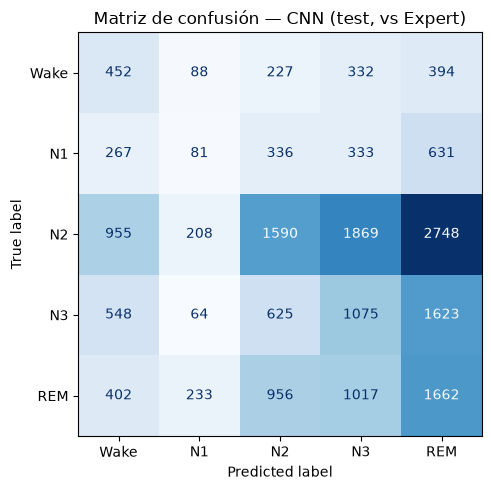

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=range(5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Wake', 'N1', 'N2', 'N3', 'REM'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — CNN (test, vs Expert)')
plt.tight_layout(); plt.show()

## Vista de 4 clases (Wake / Light / Deep / REM)

Colapsamos las etapas NREM (**N1+N2 → Light**, **N3 → Deep**) para comparar de forma justa con el paper del dataset y con los otros notebooks. **No se reentrena**: se aplica el mismo mapeo a predicciones y target.

CNN 4 clases (test)  ->  Accuracy: 0.289 | F1-macro: 0.274 | Kappa: 0.035

              precision    recall  f1-score   support

        Wake       0.17      0.30      0.22      1493
       Light       0.50      0.25      0.33      9018
        Deep       0.23      0.27      0.25      3935
         REM       0.24      0.39      0.29      4270

    accuracy                           0.29     18716
   macro avg       0.29      0.30      0.27     18716
weighted avg       0.36      0.29      0.30     18716



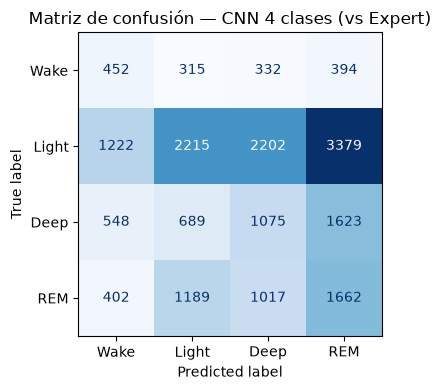

In [7]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_true4, y_pred4 = remap(y_true), remap(y_pred)

print(f"CNN 4 clases (test)  ->  Accuracy: {accuracy_score(y_true4, y_pred4):.3f} | "
      f"F1-macro: {f1_score(y_true4, y_pred4, average='macro'):.3f} | "
      f"Kappa: {cohen_kappa_score(y_true4, y_pred4):.3f}")
print()
print(classification_report(y_true4, y_pred4, target_names=names4))

cm4 = confusion_matrix(y_true4, y_pred4, labels=range(4))
disp4 = ConfusionMatrixDisplay(cm4, display_labels=names4)
fig, ax = plt.subplots(figsize=(5, 4))
disp4.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — CNN 4 clases (vs Expert)')
plt.tight_layout(); plt.show()